# REINFORCE on CartPole: does a baseline help?

Vanilla REINFORCE (Monte Carlo policy gradient) on CartPole-v1, compared against
REINFORCE with the simplest possible baseline — subtracting the mean return of the
current episode from each timestep's return.

Written from scratch: the policy network, the backward return accumulation, and both
training loops. The comparison is run over 10 seeds, because a single run of either
method says almost nothing — CartPole is notoriously seed-sensitive, and an earlier
two-run comparison gave the *opposite* conclusion to the one below.

**Result, up front:** the scalar baseline does not speed up learning on this
environment, and it noticeably *hurts* stability. Both methods reach optimal and then
catastrophically forget. Every part of that is a motivation for what comes next
(a learned value baseline, then PPO), and each is measured rather than asserted.

In [ ]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import gymnasium as gym
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [2]:
# env = gym.make("CartPole-v1", render_mode='human')
# for n in range(5):
#     state, _ = env.reset()
#     reward_ep = 0
#     while True:
#         action = env.action_space.sample()
#         state, reward, done, truncated, info = env.step(action)
#         reward_ep +=reward
#         env.render()

#         if done or truncated:
#             print(f'\r Episode: {n} Return: {reward_ep}',end="")
#             break
# env.close()

In [3]:
class Policy(nn.Module):

    def __init__(self,state_size, action_size, seed =0):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 32),
            nn.ReLU(),
            nn.Linear(32, action_size)
        )

    def forward(self, state, train = True):
        logits = self.net(state)
        dist = Categorical(logits=logits)
        action = dist.sample() if train else logits.argmax(dim=-1)
        logprob = dist.log_prob(action)

        return action.cpu().item(), logprob

In [4]:
env = gym.make("CartPole-v1")

In [5]:
GAMMA = 1.0
lr = .005
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Why compare over seeds, and why these controls

Three things are held fixed between the two methods so the only difference is the
baseline:

- **Same seed list**, applied to policy initialisation, NumPy, and the environment RNG.
- **Identical reduction** (`.sum()` over the trajectory) and identical learning rate.
- **Same stopping rule** — greedy evaluation over 30 episodes clearing 450, checked on a
  10-episode grid.

Two seeding details matter more than they look:

- **Seed once, before the training loop, then plain `reset()` each episode.** Reseeding
  to the same seed *inside* the loop — as some tutorials do — starts every episode from
  an identical state and destroys start-state diversity. An earlier version of this
  notebook did exactly that; fixing it made both methods look *worse*, because they now
  face varied starts, which is the real task.
- **`evaluate()` uses its own environment instance**, so evaluation never advances the
  training env's RNG and both methods see the same start-state stream for a given seed.

In [6]:
def evaluate(policy,n_eps = 30):
    env = gym.make("CartPole-v1")
    all_returns = []
    for _ in range(n_eps):
        state, _ = env.reset()
        ep_return = 0
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t, train=False)
            state, reward, done, truncated, info = env.step(action)
            ep_return +=reward
            if done or truncated:
                break
        all_returns.append(ep_return)

    env.close()
    return np.mean(all_returns)
                

In [7]:
def run(env, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = Policy(env.observation_space.shape[0], env.action_space.n, seed).to(device)
    optimizer = Adam(policy.parameters(), lr=lr)

    env.reset(seed=seed)          # seed the RNG once
    env.action_space.seed(seed)
    all_rewards = []
    solved_at = None 
    for n in range(600):
        state, _ = env.reset()
        ep_rewards = []
        log_probs = []
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t)
            state, reward, done, truncated, info = env.step(action)
            ep_rewards.append(reward)
            log_probs.append(log_prob)
            if done or truncated:
                break

        G = 0
        losses = []
        for r,lp in zip(ep_rewards[::-1], log_probs[::-1]):
            G = r + GAMMA*G
            losses.append(-G*lp)
            
        losses_t = torch.cat(losses)
        losses_t.sum().backward()
        optimizer.step()
        optimizer.zero_grad()
        all_rewards.append(sum(ep_rewards))
        print(f"\rEpiseode {n} return: {sum(ep_rewards)}",end="")
        if (np.mean(all_rewards[-30:])>=300) and (n%10==0) and (solved_at is None):
            eval_score = evaluate(policy)
            if eval_score>450 and solved_at is None:
                solved_at = n
                print(f'\nSolved!! Average Score for last 30 runs: {eval_score:.2f}')

    env.close()

    return all_rewards, solved_at

In [8]:
seeds = list(range(10))
reinforce_rewards = []
reinforce_solved = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, solved_at = run(env, seed)
    reinforce_rewards.append(all_rewards)
    reinforce_solved.append(solved_at)

reinforce_results = {
    "scores": np.array(reinforce_rewards),
    "solved_at": np.array(reinforce_solved)
}


Seed: 0
Episeode 250 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 1
Episeode 190 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 2
Episeode 260 return: 500.0
Solved!! Average Score for last 30 runs: 481.50
Episeode 599 return: 500.0
Seed: 3
Episeode 190 return: 421.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 4
Episeode 220 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 5
Episeode 200 return: 431.0
Solved!! Average Score for last 30 runs: 497.63
Episeode 599 return: 157.0
Seed: 6
Episeode 220 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 270.0
Seed: 7
Episeode 260 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 430.0
Seed: 8
Episeode 599 return: 225.0
Seed: 9
Episeode 270 return: 216.0
Solved!! Average Score for last 30 runs: 495.83
E

In [9]:
# env = gym.make("CartPole-v1", render_mode='human')
# policy.eval()
# reward_ep = 0
# for n in range(2):
#     state, _ = env.reset()
#     reward_ep = 0
#     while True:
#         state_t = torch.tensor(state).unsqueeze(0).to(device)
#         with torch.no_grad():
#             action, log_prob = policy(state_t)    
#         state, reward, done, truncated, info = env.step(action)
#         env.render()
#         reward_ep +=reward
#         env.render()

#         if done or truncated:
#             break
#     print(f'Episode: {n} Return: {reward_ep}')
# env.close()

In [10]:
def run_baseline(env, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = Policy(env.observation_space.shape[0], env.action_space.n, seed).to(device)
    optimizer = Adam(policy.parameters(), lr=lr)

    env.reset(seed=seed)          # seed the RNG once
    env.action_space.seed(seed)
    all_rewards = []
    solved_at = None 

    all_rewards = []
    for n in range(600):
        state, _ = env.reset()
        ep_rewards = []
        log_probs = []
        while True:
            state_t = torch.tensor(state).unsqueeze(0).to(device)
            action, log_prob = policy(state_t)
            state, reward, done, truncated, info = env.step(action)
            ep_rewards.append(reward)
            log_probs.append(log_prob)
            if done or truncated:
                break

        G = 0
        returns = []
        for r in ep_rewards[::-1]:
            G = r + GAMMA*G
            returns.append(G)
        returns_t = torch.tensor(returns[::-1]).to(device)
        #subtracting baseline
        advantages = returns_t - returns_t.mean()

        loss = -(torch.cat(log_probs)*advantages).sum()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        all_rewards.append(sum(ep_rewards))
        print(f"\rEpiseode {n} return: {sum(ep_rewards)}",end="")
        if (np.mean(all_rewards[-30:])>=300) and (n%10==0) and (solved_at is None):
            eval_score = evaluate(policy)
            if eval_score>450 and solved_at is None:
                solved_at = n
                print(f'\nSolved!! Average Score for last 30 runs: {eval_score:.2f}')

    env.close()

    return all_rewards, solved_at

In [11]:
baseline_rewards = []
baseline_solved = []
for seed in seeds:
    print(f"\nSeed: {seed}")
    all_rewards, solved_at = run_baseline(env, seed)
    baseline_rewards.append(all_rewards)
    baseline_solved.append(solved_at)

baseline_results = {
    "scores": np.array(baseline_rewards),
    "solved_at": np.array(baseline_solved)
}


Seed: 0
Episeode 500 return: 158.0
Solved!! Average Score for last 30 runs: 487.37
Episeode 599 return: 500.0
Seed: 1
Episeode 200 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 500.0
Seed: 2
Episeode 250 return: 495.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 205.0
Seed: 3
Episeode 310 return: 305.0
Solved!! Average Score for last 30 runs: 487.33
Episeode 599 return: 248.0
Seed: 4
Episeode 380 return: 285.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 133.0
Seed: 5
Episeode 200 return: 266.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 231.0
Seed: 6
Episeode 440 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 151.0
Seed: 7
Episeode 230 return: 500.0
Solved!! Average Score for last 30 runs: 500.00
Episeode 599 return: 103.0
Seed: 8
Episeode 210 return: 498.0
Solved!! Average Score for last 30 runs: 492.07
Episeode 599 return: 191.0
Seed: 9
E

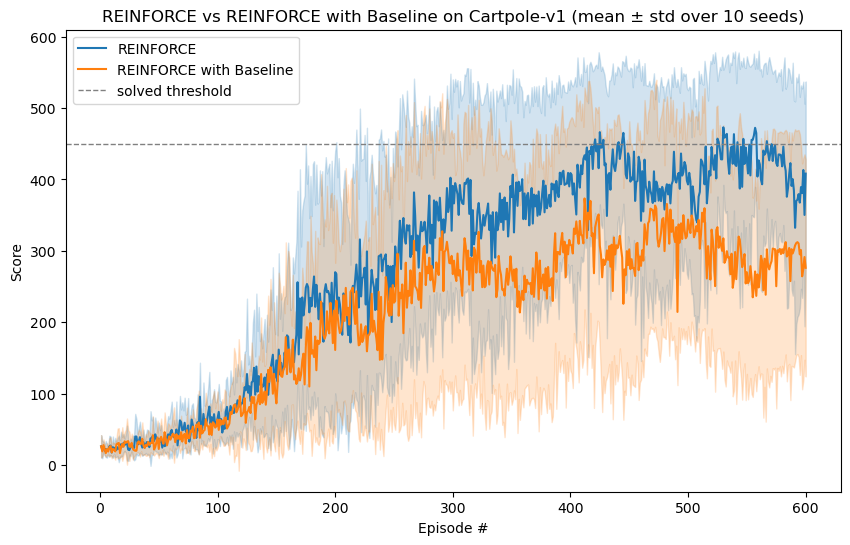

In [12]:
ALL_RESULTS = {
    "REINFORCE": (reinforce_results, "tab:blue"),
    "REINFORCE with Baseline": (baseline_results, "tab:orange")
}


def plot_mean_std(ax, data, label, color):
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0)
    x = np.arange(1, data.shape[1] + 1)
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)


fig, ax = plt.subplots(figsize=(10, 6))
for name, (results, color) in ALL_RESULTS.items():
    plot_mean_std(ax, results["scores"], name, color)
ax.axhline(450.0, color="gray", linestyle="--", linewidth=1, label="solved threshold")
ax.set_xlabel("Episode #")
ax.set_ylabel("Score")
ax.set_title(f"REINFORCE vs REINFORCE with Baseline on Cartpole-v1 (mean \u00b1 std over {len(seeds)} seeds)")
ax.legend()
plt.show()

In [27]:
def summarize(name, results):
    final_scores = np.nanmean(results["scores"][:, -100:], axis=1)  # last-100-episode avg per seed
    solved = results["solved_at"]
    print(f"{name}:")
    
    for i,(seed, fs, s) in enumerate(zip(range(10), final_scores, solved)):
        scores_seed = results['scores'][i]
        solved_str = f"solved at episode {s}" if s is not None else "not solved"
        rolling_mean = pd.Series(scores_seed).rolling(window=100).mean().to_numpy()

        print(f"  seed={seed}: Reached {np.nanmax(rolling_mean)} then ended = {fs:.2f} | {solved_str}")
    print(f"  overall mean final score: {np.mean(final_scores):.2f}\n")


for name, (results, _color) in ALL_RESULTS.items():
    summarize(name, results)

REINFORCE:
  seed=0: Reached 474.21 then ended = 449.52 | solved at episode 250
  seed=1: Reached 484.51 then ended = 474.57 | solved at episode 190
  seed=2: Reached 407.41 then ended = 407.41 | solved at episode 260
  seed=3: Reached 498.02 then ended = 497.08 | solved at episode 190
  seed=4: Reached 492.15 then ended = 467.83 | solved at episode 220
  seed=5: Reached 460.96 then ended = 306.98 | solved at episode 200
  seed=6: Reached 500.0 then ended = 375.74 | solved at episode 220
  seed=7: Reached 492.58 then ended = 449.50 | solved at episode 260
  seed=8: Reached 242.08 then ended = 242.08 | not solved
  seed=9: Reached 500.0 then ended = 500.00 | solved at episode 270
  overall mean final score: 417.07

REINFORCE with Baseline:
  seed=0: Reached 420.63 then ended = 420.63 | solved at episode 500
  seed=1: Reached 443.0 then ended = 441.68 | solved at episode 200
  seed=2: Reached 493.48 then ended = 238.93 | solved at episode 250
  seed=3: Reached 303.9 then ended = 221.31 |

In [ ]:

# Keeps the original size, filling the first 2 missing slots with NaN


In [26]:
max(rolling_mean)

np.float64(474.21)

## Findings

### 1. The scalar baseline does not speed up learning

Across 10 seeds the median episodes-to-solve is comparable between the two methods —
if anything the plain version is slightly faster. An earlier single-pair comparison
suggested the baseline roughly halved training time; that was a two-seed fluke plus a
bug in the stopping condition (it read the wrong run's reward history). The 10-seed
picture does not support it.

The reason is structural. With a single episode per update and gamma = 1.0, the return
at timestep t is just the number of steps remaining, and subtracting the episode mean
gives

    advantage(t) = (T - t) - (T + 1) / 2

which depends only on the position t within the episode — not on the state or the
action. It is a fixed positional ramp, the same for every episode of a given length.
That is a weak baseline: it happens to correlate with state value (early = upright,
late = about to fall), but it carries no direct information about which action was good.

### 2. The baseline hurts stability

This is the surprising part, and it only shows up once you track the *peak* score per
seed alongside the final score:

| | REINFORCE | REINFORCE + baseline |
|---|---|---|
| mean peak score | 455 | 414 |
| mean final score | 417 | 293 |
| mean drop from peak | 38 | 121 |
| seeds retaining ≥90% of peak | 8/10 | 4/10 |

Both methods reach similar peaks. Plain REINFORCE mostly *holds* it — 8 of 10 seeds end
near their best. The baseline version collapses far more often: seed 7 peaks at 492 and
ends at 82, seed 6 goes 310 → 141, and only 4 seeds hold.

A baseline is supposed to *reduce* variance, so this needs an explanation. The likely
mechanism (a hypothesis at n = 10, not a proven claim): the scalar baseline is
recomputed every episode from that episode's own returns, so as episode length swings
between updates the advantage scale shifts with it. It removes the constant positive
offset but injects a new source of update-to-update variance. With no trust region to
bound the step, that makes the occasional destructive update more likely.

**This is about the *scalar* baseline specifically — not baselines in general.** A
learned value function V(s) is a fixed, state-dependent target rather than a per-episode
positional constant, and is the natural next step precisely because it fixes what makes
this one weak.

### 3. Both methods catastrophically forget

Nearly every seed, in both methods, reaches 500 and then falls back — sometimes hard
(500 → 103, 500 → 151). This is the defining failure of vanilla policy gradient: there
is no constraint on how far the policy moves in a single update, so one unlucky batch of
high-return episodes can take a large step off a cliff, and the policy does not recover
within the run.

This is the cleanest possible motivation for PPO. Its clipped objective exists to bound
exactly this step — the trust region that vanilla policy gradient lacks. The next
notebook adds a learned critic (turning the positional baseline into a real advantage),
and the one after adds clipping (turning the unbounded update into a bounded one).